In [1]:
import numpy as np
import os,glob
from pathlib import Path
from helper import deltaR

from computeEfficiencies import getSR,preSelection,getObjects,passTrigger, electron_reco_smooth, electron_reco_1D, createdBeforeECAL, createdBeforeSCT
DelphesLLP_path = Path(os.path.abspath("./DelphesLLP"))
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(DelphesLLP_path,"external")

import ROOT
ROOT.gSystem.Load(os.path.join(DelphesLLP_path,"libDelphes.so"))
ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')
from ROOT import TFile
# Cosmetics:
import matplotlib.pyplot as plt

import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

Welcome to JupyROOT 6.30/06


In [2]:
# inputFile = './pp2selsel/Events/run_09/selectron_400GeV_1.000ns_delphes_events.root'
# inputFile = './pp2selsel_scan/Events/run_06/selectron_100GeV_0.100ns_delphes_events.root'
mass = 400.0
tau0 = 10.0
inputFile = list(glob.glob(f'./pp2selsel_scan/Events/run_*/selectron_{int(mass)}GeV_{tau0:.3f}ns_delphes_events.root'))[0]


f = TFile(inputFile,'read')
DelphesTree = f.Get('Delphes')
nevts = DelphesTree.GetEntries()

totalweight = 0
ct=0

d0A = []
d0B = []
pTA = []
pTB = []
etaA = []
etaB = []
effA = []
effB = []
effA_smooth = []
effB_smooth = []
effA_1D = []
effB_1D = []
for entry in range(nevts):
    DelphesTree.GetEntry(entry)
    ct+=1

    weight = float(DelphesTree.Weight.At(0).Weight)    
    totalweight += weight
    _,muons,electrons = getObjects(DelphesTree)
    leptons_preSel = preSelection(muons,electrons)
    if not leptons_preSel:
        continue
    if any(lep.PT < 65. for lep in leptons_preSel):
        continue
    if any(abs(lep.D0) < 3. for lep in leptons_preSel):
        continue
    # if any(abs(lep.D0) > 300. for lep in leptons_preSel):
        # continue
    if len(leptons_preSel) < 2:
        continue
    if any(abs(lep.PID) != 11 for lep in leptons_preSel):
        continue
    if deltaR(leptons_preSel[0], leptons_preSel[1]) < 0.2:
            continue
    if not passTrigger(leptons_preSel):
        continue

    eff_reco_A = electron_reco_smooth.efficiency(method='binned',Lepton_p_textT_GeV=leptons_preSel[0].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[0].D0))
    eff_reco_B = electron_reco_smooth.efficiency(method='binned',Lepton_p_textT_GeV=leptons_preSel[1].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[1].D0))
    
    eff_reco_A_smooth = electron_reco_smooth.efficiency(method='smooth',Lepton_p_textT_GeV=leptons_preSel[0].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[0].D0))
    eff_reco_B_smooth = electron_reco_smooth.efficiency(method='smooth',Lepton_p_textT_GeV=leptons_preSel[1].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[1].D0))
    
    eff_reco_A_1D = electron_reco_1D.efficiency(method='binned', Lepton_p_textT_GeV=leptons_preSel[0].PT, Lepton_d_0_mm=abs(leptons_preSel[0].D0))
    eff_reco_B_1D = electron_reco_1D.efficiency(method='binned', Lepton_p_textT_GeV=leptons_preSel[1].PT, Lepton_d_0_mm=abs(leptons_preSel[1].D0))

    if abs(leptons_preSel[0].Z0) > 1500.0:
         eff_reco_A_smooth = 0.0
    elif not createdBeforeECAL(leptons_preSel[0]) and abs(leptons_preSel[0].PID) == 11:
         eff_reco_A_smooth = 0.0
    elif leptons_preSel[0].R > 300.:
         eff_reco_A_smooth = 0.0
    # elif not createdBeforeSCT(leptons_preSel[0]) and abs(leptons_preSel[0].PID) == 11:
        # eff_reco_A_smooth = 0.0

    if abs(leptons_preSel[1].Z0) > 1500.0:
         eff_reco_B_smooth = 0.0   
    elif not createdBeforeECAL(leptons_preSel[1]) and abs(leptons_preSel[1].PID) == 11:
         eff_reco_B_smooth = 0.0
    elif leptons_preSel[1].R > 300.:
         eff_reco_B_smooth = 0.0    
    # elif not createdBeforeSCT(leptons_preSel[1]) and abs(leptons_preSel[1].PID) == 11:
        #  eff_reco_B_smooth = 0.0

    # if eff_reco_A == 0. or eff_reco_B == 0.:
    #     print(f"eff A = {eff_reco_A}, eff B = {eff_reco_B}")
    #     print(f"pT A = {leptons_preSel[0].PT}, d0 A = {leptons_preSel[0].D0}")
    #     print(f"pT B = {leptons_preSel[1].PT}, d0 B = {leptons_preSel[1].D0}")
    #     break
    d0A.append(abs(leptons_preSel[0].D0))
    d0B.append(abs(leptons_preSel[1].D0))
    pTA.append(leptons_preSel[0].PT)
    pTB.append(leptons_preSel[1].PT)
    etaA.append(leptons_preSel[0].Eta)
    etaB.append(leptons_preSel[1].Eta)
    effA.append(eff_reco_A)
    effB.append(eff_reco_B)
    effA_smooth.append(eff_reco_A_smooth)
    effB_smooth.append(eff_reco_B_smooth)
    effA_1D.append(eff_reco_A_1D)
    effB_1D.append(eff_reco_B_1D)

In [3]:
data = np.array(list(zip(d0A,d0B,pTA,pTB,etaA,etaB,effA,effB,effA_smooth,effB_smooth,effA_1D,effB_1D)), dtype=np.dtype([('d0A', float),('d0B', float),('pTA', float),('pTB', float),('etaA', float),('etaB', float),('effA', float),('effB', float),('effA_smooth', float),('effB_smooth', float),('effA_1D', float),('effB_1D', float)]))
data_filtered = data[(data['d0A'] < 300.0) & (data['d0B'] < 300.0)]

In [4]:
# Efficiency edges from ATLAS
edges = np.array([[65.,300.],[135.,300.],[205.,300.],[205.,250.],[275.,250.],[345.,250.],[345.,200.],[415.,200.],[415.,150.],[485.,150.],[555.,150.],[555.,100.],[770.,100.]])

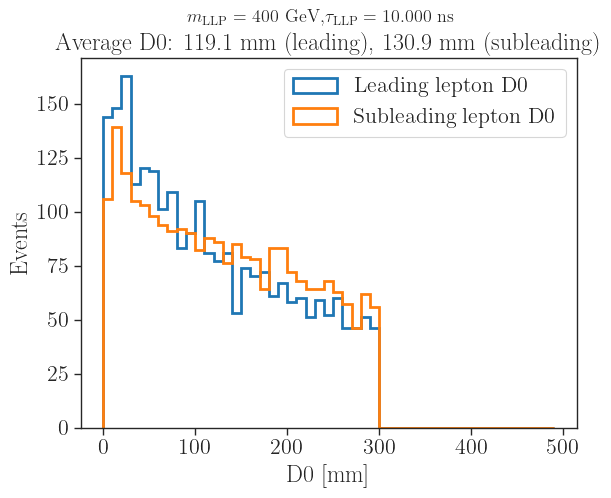

In [5]:
use_data = data_filtered
plt.hist(use_data['d0A'],bins=np.arange(0,500,10).tolist(),histtype='step',label='Leading lepton D0',linewidth=2)
plt.hist(use_data['d0B'],bins=np.arange(0,500,10).tolist(),histtype='step',label='Subleading lepton D0',linewidth=2)
plt.xlabel('D0 [mm]')
plt.ylabel('Events')
plt.title(f'Average D0: {np.mean(use_data["d0A"]):.1f} mm (leading), {np.mean(use_data["d0B"]):.1f} mm (subleading)')
plt.suptitle(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.legend()
plt.show()

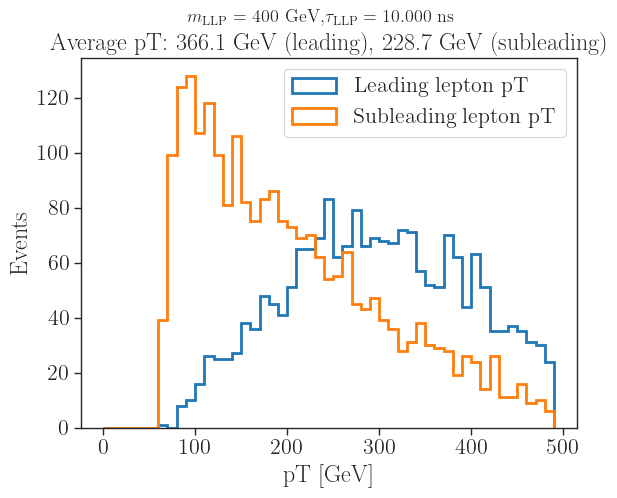

In [6]:
use_data = data_filtered
plt.hist(use_data['pTA'],bins=np.arange(0,500,10).tolist(),histtype='step',label='Leading lepton pT',linewidth=2)
plt.hist(use_data['pTB'],bins=np.arange(0,500,10).tolist(),histtype='step',label='Subleading lepton pT',linewidth=2)
plt.xlabel('pT [GeV]')
plt.ylabel('Events')
plt.title(f'Average pT: {np.mean(use_data["pTA"]):.1f} GeV (leading), {np.mean(use_data["pTB"]):.1f} GeV (subleading)')
plt.suptitle(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.legend()
plt.show()

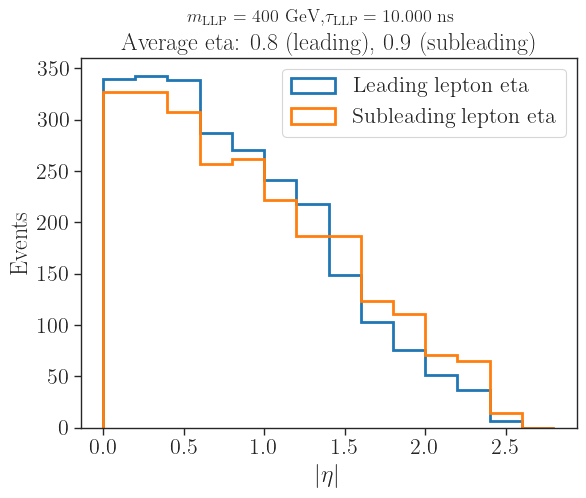

In [7]:
use_data = data_filtered
plt.hist(np.abs(use_data['etaA']),bins=np.arange(0,3,0.2).tolist(),histtype='step',label='Leading lepton eta',linewidth=2)
plt.hist(np.abs(use_data['etaB']),bins=np.arange(0,3,0.2).tolist(),histtype='step',label='Subleading lepton eta',linewidth=2)
plt.xlabel(r'$|\eta|$')
plt.ylabel('Events')
plt.title(f'Average eta: {np.mean(np.abs(use_data["etaA"])):.1f} (leading), {np.mean(np.abs(use_data["etaB"])):.1f} (subleading)')
plt.suptitle(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.legend()
plt.show()

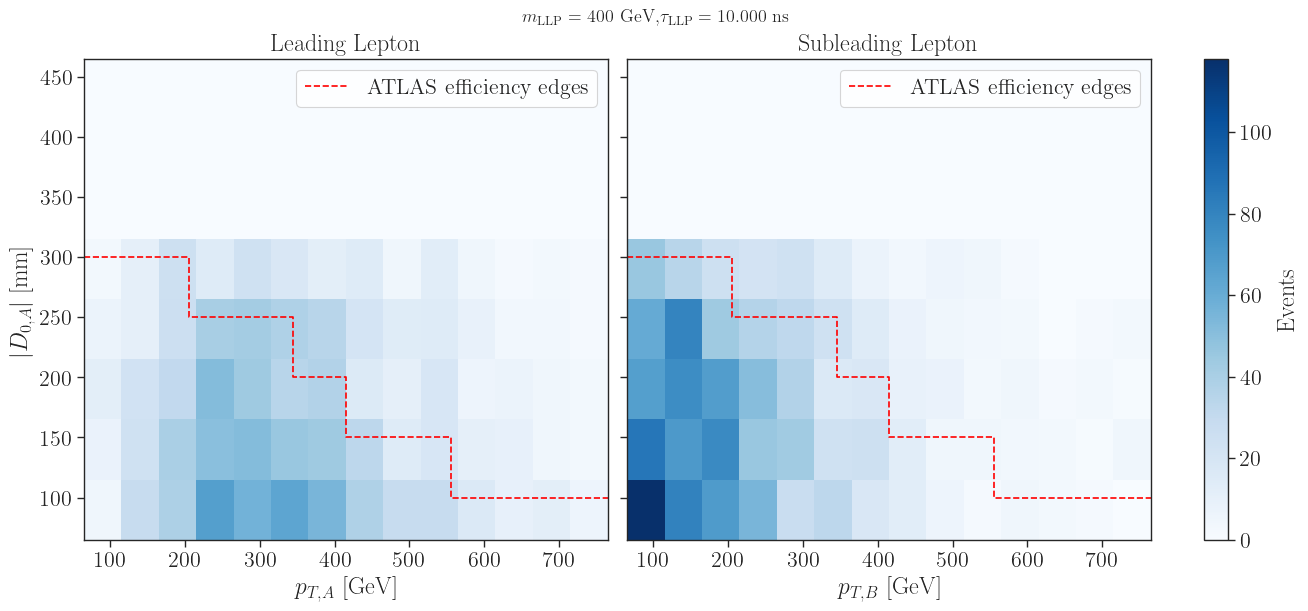

In [8]:
xbins = np.arange(65.0, 800., 50.)
ybins = np.arange(65.0, 500, 50.)
use_data = data_filtered

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True, constrained_layout=True)

hist_a = axes[0].hist2d(use_data['pTA'], use_data['d0A'], bins=[xbins, ybins], cmap='Blues')
axes[0].set_xlabel(r'$p_{T,A}$ [GeV]')
axes[0].set_ylabel(r'$|D_{0,A}|$ [mm]')
axes[0].set_title('Leading Lepton')


hist_b = axes[1].hist2d(use_data['pTB'], use_data['d0B'], bins=[xbins, ybins], cmap='Blues')
axes[1].set_xlabel(r'$p_{T,B}$ [GeV]')
axes[1].set_title('Subleading Lepton')

axes[0].plot(edges[:,0], edges[:,1], color='red', linestyle='--', label='ATLAS efficiency edges')
axes[0].vlines(x=65.,ymin=3.,ymax=300.,color='red', linestyle='--')
axes[0].legend()
axes[1].plot(edges[:,0], edges[:,1], color='red', linestyle='--', label='ATLAS efficiency edges')
axes[1].vlines(x=65.,ymin=3.,ymax=300.,color='red', linestyle='--')
axes[1].legend()

vmax = max(hist_a[0].max(), hist_b[0].max())
hist_a[3].set_clim(0, vmax)
hist_b[3].set_clim(0, vmax)
fig.colorbar(hist_a[3], ax=axes, label='Events')
plt.suptitle(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.show()


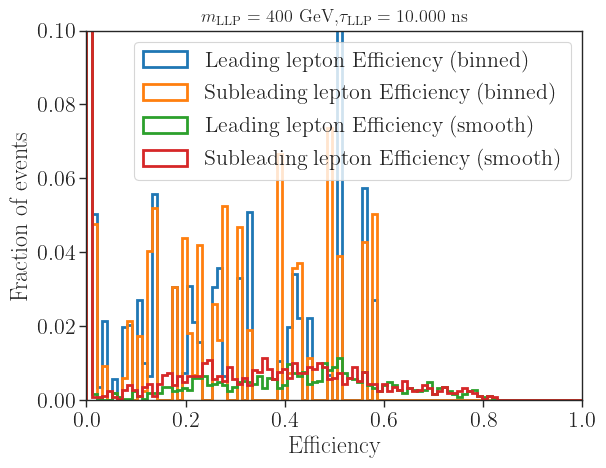

In [9]:
use_data = data_filtered

plt.hist(use_data['effA'],bins=np.linspace(0,1,100).tolist(),histtype='step',label='Leading lepton Efficiency (binned)',linewidth=2,weights=np.ones_like(use_data['effA'])/len(use_data['effA']))
plt.hist(use_data['effB'],bins=np.linspace(0,1,100).tolist(),histtype='step',label='Subleading lepton Efficiency (binned)',linewidth=2,weights=np.ones_like(use_data['effB'])/len(use_data['effB']))
plt.hist(use_data['effA_smooth'],bins=np.linspace(0,1,100).tolist(),histtype='step',label='Leading lepton Efficiency (smooth)',linewidth=2,weights=np.ones_like(use_data['effA_smooth'])/len(use_data['effA_smooth']))
plt.hist(use_data['effB_smooth'],bins=np.linspace(0,1,100).tolist(),histtype='step',label='Subleading lepton Efficiency (smooth)',linewidth=2,weights=np.ones_like(use_data['effB_smooth'])/len(use_data['effB_smooth']))
plt.xlabel('Efficiency')
plt.ylabel('Fraction of events')
plt.xlim(0.,1.0)
plt.ylim(0.,0.1)
plt.legend()
plt.title(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.show()

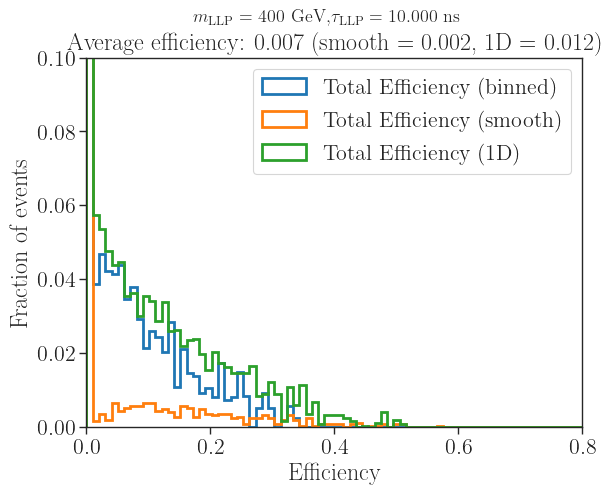

In [10]:
use_data = data_filtered
effTot = [eA*eB for eA,eB in zip(use_data['effA'],use_data['effB'])]
effTot_smooth = [eA*eB for eA,eB in zip(use_data['effA_smooth'],use_data['effB_smooth'])]
effTot_1D = [eA*eB for eA,eB in zip(use_data['effA_1D'],use_data['effB_1D'])]
plt.hist(effTot,bins=np.linspace(0,1,100).tolist(),histtype='step',label='Total Efficiency (binned)',linewidth=2,weights=np.ones_like(use_data['effA'])/len(use_data['effA']))
plt.hist(effTot_smooth,bins=np.linspace(0,1,100).tolist(),histtype='step',label='Total Efficiency (smooth)',linewidth=2,weights=np.ones_like(use_data['effA_smooth'])/len(use_data['effA_smooth']))
plt.hist(effTot_1D,bins=np.linspace(0,1,100).tolist(),histtype='step',label='Total Efficiency (1D)',linewidth=2,weights=np.ones_like(use_data['effA_1D'])/len(use_data['effA_1D']))
plt.xlabel('Efficiency')
plt.ylabel('Fraction of events')
plt.xlim(0.,0.8)
plt.legend()
plt.title(f'Average efficiency: {np.mean(effTot)*len(use_data)/len(data):.3f} (smooth = {np.mean(effTot_smooth)*len(use_data)/len(data):.3f}, 1D = {np.mean(effTot_1D)*len(use_data)/len(data):.3f})')
plt.suptitle(r'$m_{\rm LLP} =$' + f' {mass:.0f} GeV,' + r'$\tau_{\rm LLP} =$' +  f' {tau0:.3f} ns', fontsize=13)
plt.ylim(0.0,0.1)
plt.show()

In [11]:
# eff with all cuts = 0.002
# eff with createBeforeSCT cut = 0.003
0.003/0.002

1.5